<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hackathons/dsn/000_DSN_Hackathon_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install scikit-learn --upgrade

^C


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

In [ ]:
def get_data(filename: str) -> pd.DataFrame:
    dataset_path = os.path.join("Datasets", "dsn_house_predict",  filename) # hardcoded
    return pd.read_csv(dataset_path)

### Quick Look

In [ ]:
df = get_data("Housing_dataset_train.csv")

In [ ]:
df.sort_values(by="price")

,ID,loc,title,bedroom,bathroom,parking_space,price
4481,2606,Gombe,Cottage,1.0,2.0,1.0,4.319673e+05
13538,847,Gombe,Cottage,1.0,1.0,1.0,4.555912e+05
667,599,Kebbi,NaN,1.0,1.0,4.0,5.376227e+05
2759,1745,Gombe,Apartment,1.0,2.0,1.0,5.520169e+05
13446,1229,Kebbi,Flat,NaN,1.0,4.0,5.716762e+05
...,...,...,...,...,...,...,...
8507,1458,NaN,Mansion,3.0,2.0,4.0,1.404257e+07
11375,683,Lagos,Mansion,4.0,1.0,NaN,1.540273e+07
3793,1119,NaN,Mansion,5.0,1.0,3.0,1.550231e+07
1734,2026,Lagos,Mansion,5.0,NaN,NaN,1.621672e+07


In [ ]:
df["title"].value_counts()

title
Flat                    1372
Apartment               1331
Townhouse               1327
Mansion                 1322
Detached duplex         1312
Penthouse               1306
Semi-detached duplex    1299
Bungalow                1293
Terrace duplex          1266
Cottage                  450
Name: count, dtype: int64

In [ ]:
df.drop(columns=["ID"], inplace=True) # drop the Identifier column

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   loc            12187 non-null  object 
 1   title          12278 non-null  object 
 2   bedroom        12201 non-null  float64
 3   bathroom       12195 non-null  float64
 4   parking_space  12189 non-null  float64
 5   price          14000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 656.4+ KB


In [ ]:
df.describe()

,bedroom,bathroom,parking_space,price
count,12201.000000,12195.000000,12189.000000,1.400000e+04
mean,4.308171,3.134235,3.169825,2.138082e+06
std,2.441165,2.035950,1.599415,1.083057e+06
min,1.000000,1.000000,1.000000,4.319673e+05
25%,2.000000,1.000000,2.000000,1.393990e+06
50%,4.000000,2.000000,3.000000,1.895223e+06
75%,6.000000,5.000000,4.000000,2.586699e+06
max,9.000000,7.000000,6.000000,1.656849e+07


In [ ]:
# df[df.duplicated(subset=['ID'],keep=False)].sort_values(by="ID").head(10) remove this

array([[<Axes: title={'center': 'bedroom'}>,
        <Axes: title={'center': 'bathroom'}>],
       [<Axes: title={'center': 'parking_space'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

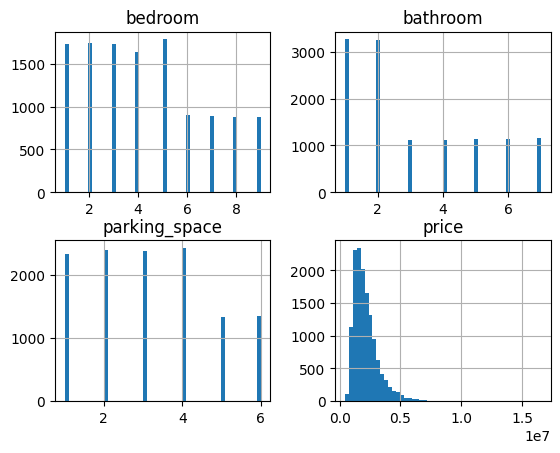

In [ ]:
df.hist(bins=50)

The target attribute seems to have a heavy tail. We may need to replace this with its logarithm

<Axes: >

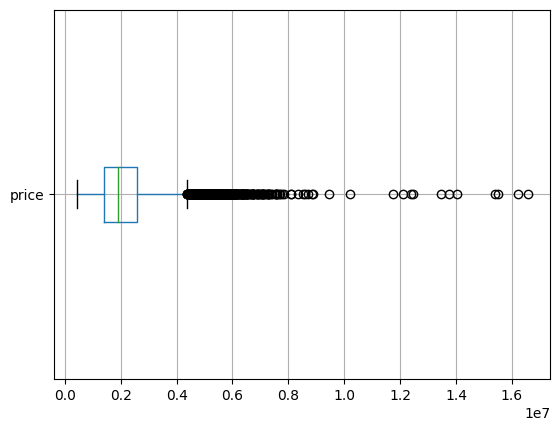

In [ ]:
df[["price"]].boxplot(vert=False)

We may also need to handle outliers as well

In [ ]:
df.corr(numeric_only=True)["price"]

bedroom          0.529145
bathroom         0.221544
parking_space    0.109211
price            1.000000
Name: price, dtype: float64

### Get the data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
seed = 99

The number of bedrooms correlates more with the price. We'll assume it is a very important criterion for predicting the price, hence, for our split, we'll want to make sure our test data is representative of all the various numbers of bedrooms

In [ ]:
# introduce a new column to handle bedroom na values for splitting sake
fill_na_value = df["bedroom"].max() + 1 # uses +1 of max value so np.nan values are split equally across the datasets too
df["bedroom_cat"] = df["bedroom"].fillna(fill_na_value)

In [ ]:
strat_train_val_set, strat_test_set = train_test_split(df, stratify=df["bedroom_cat"], test_size=0.15, random_state=seed)
strat_train_set, strat_val_set = train_test_split(strat_train_val_set, stratify=strat_train_val_set["bedroom_cat"], test_size=0.2, random_state=99)

In [ ]:
# dropping the bedroom cat attribute since it was only useful for splitting
for set_ in (strat_test_set, strat_train_set, strat_val_set):
    set_.drop(columns=["bedroom_cat"], inplace=True)

### Explore the Data

In [ ]:
from pandas.plotting import scatter_matrix

In [ ]:
# create new copy of training dataset
housing = strat_train_set.copy()

array([[<Axes: xlabel='bedroom', ylabel='bedroom'>,
        <Axes: xlabel='bathroom', ylabel='bedroom'>,
        <Axes: xlabel='parking_space', ylabel='bedroom'>,
        <Axes: xlabel='price', ylabel='bedroom'>],
       [<Axes: xlabel='bedroom', ylabel='bathroom'>,
        <Axes: xlabel='bathroom', ylabel='bathroom'>,
        <Axes: xlabel='parking_space', ylabel='bathroom'>,
        <Axes: xlabel='price', ylabel='bathroom'>],
       [<Axes: xlabel='bedroom', ylabel='parking_space'>,
        <Axes: xlabel='bathroom', ylabel='parking_space'>,
        <Axes: xlabel='parking_space', ylabel='parking_space'>,
        <Axes: xlabel='price', ylabel='parking_space'>],
       [<Axes: xlabel='bedroom', ylabel='price'>,
        <Axes: xlabel='bathroom', ylabel='price'>,
        <Axes: xlabel='parking_space', ylabel='price'>,
        <Axes: xlabel='price', ylabel='price'>]], dtype=object)

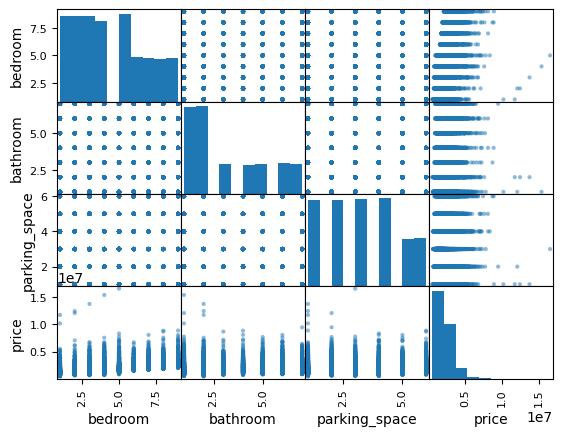

In [ ]:
scatter_matrix(housing.select_dtypes([np.number]))

In [ ]:
housing.corr(numeric_only=True)

,bedroom,bathroom,parking_space,price
bedroom,1.000000,0.230554,0.101272,0.532544
bathroom,0.230554,1.000000,0.186258,0.218791
parking_space,0.101272,0.186258,1.000000,0.100554
price,0.532544,0.218791,0.100554,1.000000


### Experimenting with attribute combinations

In [ ]:
housing["bathroom_per_room"] = housing["bathroom"] / housing["bedroom"]
housing["park_per_room"] = housing["parking_space"] / housing["bedroom"]
housing["park_per_bath"] = housing["parking_space"] / housing["bathroom"]

In [ ]:
housing.head()

,loc,title,bedroom,bathroom,parking_space,price,bathroom_per_room,park_per_room,park_per_bath
3729,Niger,Terrace duplex,6.0,2.0,2.0,1986186.185,0.333333,0.333333,1.00
3455,Jigawa,Penthouse,1.0,4.0,5.0,1432662.471,4.000000,5.000000,1.25
9293,Niger,Detached duplex,3.0,6.0,NaN,1810018.933,2.000000,NaN,NaN
5901,Anambra,NaN,4.0,1.0,1.0,1580751.452,0.250000,0.250000,1.00
5093,Anambra,Bungalow,1.0,1.0,5.0,1150434.651,1.000000,5.000000,5.00


In [ ]:
housing.corr(numeric_only=True)["price"].sort_values(ascending=False)

price                1.000000
bedroom              0.532544
bathroom             0.218791
parking_space        0.100554
park_per_bath       -0.097428
bathroom_per_room   -0.197742
park_per_room       -0.296024
Name: price, dtype: float64

### Prepare the Data

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

In [ ]:
def set_sample_weight(sample_weight):
    global sample_weight_
    sample_weight_ = sample_weight

In [ ]:
def get_sample_weight():
    global sample_weight_
    return sample_weight_

In [ ]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, n_init=10,  random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        self.n_init = n_init
    def fit(self, X, y=None, sample_weight=None):
        if type(sample_weight) == "NoneType":
            sample_weight = get_sample_weight() # get sample_weight
        self.kmeans_ = KMeans(self.n_clusters, n_init=self.n_init,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!
    def transform(self, X):
        clusters = rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
        return clusters
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

from sklearn.compose import ColumnTransformer

class CustomColumnTransformer(ColumnTransformer):
    def fit_transform(self, X, y=None, sample_weight=None):
        set_sample_weight(sample_weight) # set sample_weight
        return super().fit_transform(X, y)
    def fit(self, X, y=None, sample_weight=None):
        self.fit_transform(X, y=y, sample_weight=sample_weight)
        return self



In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
import sklearn


Let’s recap what the pipeline will do and why:
 •  Missing values in numerical features will be imputed by replacing them with the median, as most ML algorithms don’t expect missing values. As for the categorical feature, any missing values will be replaced by the most frequent category.
 •  The categorical feature will be one-hot encoded, as most ML algorithms only accept numerical inputs.
 •  A few ratio features will be computed and added: bedrooms_ratio , rooms_per_house and people_per_house . Hopefully these will better correlate with the median housing value, and thereby help the ML models.
 •  A few cluster similarity features will also be added. These will likely be more useful to the model than latitude and longitude.
 •  Features with a long tail will be replaced by their logarithm, as most models prefer features with roughly uniform or Gaussian distributions.
 •  All numerical features will be standardized, as most ML algorithms prefer when all features have roughly the same scale.

In [ ]:

def merge_loc_title(X):
    return  np.c_[X, X[:, [0]] + X[:, [1]]]

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def merge_name(function_transformer, feature_names_in):
    return ["loc", "title", "merge"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )


num_pipeline = Pipeline([
    ("num_imputer", SimpleImputer()),
    ("std_scaler", StandardScaler())
])

num_simil_pipeline = make_pipeline(
    SimpleImputer(),
    ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=seed)
)

In [ ]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="constant"),
    FunctionTransformer(merge_loc_title, feature_names_out=merge_name),
    OneHotEncoder()
)
cat_simil_pipeline = make_pipeline(
    SimpleImputer(strategy="constant"),
    OrdinalEncoder(),
    ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=seed)
)


In [ ]:
preprocessing = CustomColumnTransformer([
    ("num_pipeline", num_pipeline, ["bedroom", "bathroom", "parking_space"]),
    ("bath_per_room", ratio_pipeline(), ["bathroom", "bedroom"]),
    ("park_per_room", ratio_pipeline(), ["parking_space", "bedroom"]),
    ("park_per_bath", ratio_pipeline(), ["parking_space", "bathroom"]),
    ("num_attrib_simil", num_simil_pipeline, ["bathroom", "parking_space", "bathroom"]),
    ("cat_attrib_simil_pipeline", cat_simil_pipeline, make_column_selector(dtype_include=object)),
    ("cat_pipeline", cat_pipeline, make_column_selector(dtype_include=object)),
])

labels_preprocessing = make_pipeline(
    (FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out="one-to-one")),
    (StandardScaler())
)

In [ ]:
preprocessing.get_params()

{'n_jobs': None,
 'remainder': 'drop',
 'sparse_threshold': 0.3,
 'transformer_weights': None,
 'transformers': [('num_pipeline',
   Pipeline(steps=[('num_imputer', SimpleImputer()),
                   ('std_scaler', StandardScaler())]),
   ['bedroom', 'bathroom', 'parking_space']),
  ('bath_per_room',
   Pipeline(steps=[('simpleimputer', SimpleImputer()),
                   ('functiontransformer',
                    FunctionTransformer(feature_names_out=<function ratio_name at 0x00000189A0DAC040>,
                                        func=<function column_ratio at 0x00000189A0DAC220>)),
                   ('standardscaler', StandardScaler())]),
   ['bathroom', 'bedroom']),
  ('park_per_room',
   Pipeline(steps=[('simpleimputer', SimpleImputer()),
                   ('functiontransformer',
                    FunctionTransformer(feature_names_out=<function ratio_name at 0x00000189A0DAC040>,
                                        func=<function column_ratio at 0x00000189A0DAC220>))

### ShortList Promising Models

In [ ]:
def display_scores(scores):
    print(f"Mean Score: {scores.mean()}\n Std Deviation: {scores.std()}")


In [ ]:
def shortListModels(models, X_train, y_train):
    for model in models:
        print(f"Running {model}")
        # single short train
        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        rmse = mean_squared_error(y_train, y_pred, squared=False)

        print("single shot scores")
        display_scores(rmse)

        # cross validate
        cv_rmse = cross_val_score(model, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5)
        print("cross val scores")
        display_scores(-cv_rmse)
        print("\n")



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import TransformedTargetRegressor
import tensorflow
from tensorflow import keras

In [ ]:
forest_reg = RandomForestRegressor()
linear_reg = LinearRegression()
knn_reg = KNeighborsRegressor()
tree_reg = DecisionTreeRegressor()

In [ ]:
housing = strat_train_set.copy()

In [ ]:
y_train = housing["price"]
X_train_prepared = preprocessing.fit_transform(housing)
X_val_prepared = preprocessing.transform(strat_val_set)
y_val = strat_val_set["price"]

In [ ]:
linear_model = TransformedTargetRegressor(linear_reg, transformer=labels_preprocessing)
knn_model = TransformedTargetRegressor(knn_reg, transformer=labels_preprocessing)
tree_model = TransformedTargetRegressor(tree_reg, transformer=labels_preprocessing)
forest_model = TransformedTargetRegressor(forest_reg, transformer=labels_preprocessing)

In [ ]:
models = [forest_model]
shortListModels(models, X_train_prepared, y_train)

Running TransformedTargetRegressor(regressor=RandomForestRegressor(),
                           transformer=Pipeline(steps=[('functiontransformer',
                                                        FunctionTransformer(feature_names_out='one-to-one',
                                                                            func=<ufunc 'log'>,
                                                                            inverse_func=<ufunc 'exp'>)),
                                                       ('standardscaler',
                                                        StandardScaler())]))


In [ ]:
forest_model = joblib.load("Models/forest_model.pkl")

### Checkout a basic Neural Network

In [ ]:
housing = strat_train_set.copy()
housing_val = strat_val_set.copy()

In [ ]:
X_train_prepared = preprocessing.fit_transform(housing)
X_val_prepared = preprocessing.transform(housing_val)

y_train_prepared = labels_preprocessing.fit_transform(housing[["price"]])
y_val_prepared = labels_preprocessing.transform(housing_val[["price"]])

In [ ]:
y_val_prepared

array([[-0.85646269],
       [-1.01176767],
       [-0.37126177],
       ...,
       [ 0.58057504],
       [-1.21118772],
       [-0.66815166]])

In [ ]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=X_train_prepared.shape[1:]),
    # keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(300, activation="relu"),
    # keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1),
])

In [ ]:
opt = keras.optimizers.SGD(0.001)
model.compile(loss="mse", optimizer=opt)

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

In [ ]:
history = model.fit(X_train_prepared, y_train_prepared, epochs=1000,
                    validation_data=(X_val_prepared, y_val_prepared), callbacks=[early_stopping_cb])

Epoch 1/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.7996 - val_loss: 0.7070
Epoch 2/1000
298/298 [==============================] - 1s 2ms/step - loss: 0.6522 - val_loss: 0.6256
Epoch 3/1000
298/298 [==============================] - 1s 2ms/step - loss: 0.5941 - val_loss: 0.5804
Epoch 4/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.5556 - val_loss: 0.5454
Epoch 5/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.5236 - val_loss: 0.5157
Epoch 6/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.4949 - val_loss: 0.4884
Epoch 7/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.4684 - val_loss: 0.4634
Epoch 8/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.4437 - val_loss: 0.4400
Epoch 9/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.4205 - val_loss: 0.4181
Epoch 10/1000
298/298 [==============================] - 1s 3ms/step - loss: 0.398

In [ ]:
y_pred_inverse = model.predict(X_val_prepared)

75/75 [==============================] - 1s 3ms/step


In [ ]:
y_pred = labels_preprocessing.inverse_transform(y_pred_inverse)

In [ ]:
mean_squared_error(housing_val["price"], y_pred, squared=False)

1209021.936793649

### Fine Tuning

In [ ]:
forest_model.regressor.fit(X_train_prepared, y_train, sample_weight=y_train)

RandomForestRegressor()

In [ ]:
# cat_encoder = full_pipeline.named_transformers_["cat_pipeline"]
# cat_cols2 = cat_encoder.named_steps["cat_encoder"].categories_
# cat_prepared_cols = list(cat_cols2[0]) + list(cat_cols2[1]) + list(cat_cols2[2])
# extra_attribs = ["bath_per_room", "park_space_per_room"]
# all_cols = num_cols + extra_attribs + cat_prepared_cols
# sorted(zip(random_search_fr.best_estimator_.feature_importances_* 100, all_cols), reverse=True)

In [ ]:
forest_model.regressor.

SyntaxError: ignored

In [ ]:
preprocessing.get_params()

{'n_jobs': None,
 'remainder': 'drop',
 'sparse_threshold': 0.3,
 'transformer_weights': None,
 'transformers': [('num_pipeline',
   Pipeline(steps=[('num_imputer', SimpleImputer()),
                   ('std_scaler', StandardScaler())]),
   ['bedroom', 'bathroom', 'parking_space']),
  ('bath_per_room',
   Pipeline(steps=[('simpleimputer', SimpleImputer()),
                   ('functiontransformer',
                    FunctionTransformer(feature_names_out=<function ratio_name at 0x7c4d949d7490>,
                                        func=<function column_ratio at 0x7c4d949d7370>)),
                   ('standardscaler', StandardScaler())]),
   ['bathroom', 'bedroom']),
  ('park_per_room',
   Pipeline(steps=[('simpleimputer', SimpleImputer()),
                   ('functiontransformer',
                    FunctionTransformer(feature_names_out=<function ratio_name at 0x7c4d949d7490>,
                                        func=<function column_ratio at 0x7c4d949d7370>)),
              

In [ ]:
forest_reg?

In [ ]:
params_grid = [
    {}
]

In [ ]:
model = full_pipeline.fit(X_train_prepared, y_train_prepared)

In [ ]:
from sklearn.ensemble import VotingRegressor

In [ ]:
voting_reg = VotingRegressor(
    estimators=[
        ("lin_reg", LinearRegression()),
        ("forest_reg", RandomForestRegressor(n_estimators=94, max_features=28,
                    max_depth=30, min_samples_split=20, min_samples_leaf=1, random_state=seed)),

    ], weights=[0.8, 0.2]
)

In [ ]:
voting_reg.fit(X_train_prepared, y_train)

VotingRegressor(estimators=[('lin_reg', LinearRegression()),
                            ('forest_reg',
                             RandomForestRegressor(max_depth=30,
                                                   max_features=28,
                                                   min_samples_split=20,
                                                   n_estimators=94,
                                                   random_state=99))],
                weights=[0.8, 0.2])

In [ ]:
y_pred = voting_reg.predict(X_test_prepared)

In [ ]:
np.sqrt(mean_squared_error(y_val, y_pred))

597721.2365710859

In [ ]:
y_pred_lin = linear_reg.predict(X_val_prepared)
np.sqrt(mean_squared_error(y_val, target_scaler.inverse_transform(y_pred_lin)))

609337.062568663

In [ ]:
600875.9486856251 == best score on validation

The linearRegression model seems to be underfitting the model, as it is not regularized, this means the model is not powerful enough hence we should feed it with better features. So also for the support vector model.

Decision tree and random forest models are overfitting the training set as their training scores are a lot lower than the cross val scores. since random forest is an ensemble of decision trees, let's work on it.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
forest_param_grid = {
     "n_estimators": [3, 10, 30, 80, 100, 200],
     "max_depth": [32, 64, 72, 88, 99],
     "min_samples_split": [2, 5, 7, 13, 20, 33, 53],
     "min_samples_leaf": [1, 3, 5, 7, 9],
     "max_features":[2, 4, 6, 8, 0.3, "log2"],
     "bootstrap": [False, True],
     "random_state": [seed]
    }
forest_param_grid = [
    {"n_estimators": [ 30, 80, 94, 100, 200],
     "max_features": [4, 6, 8, 28, 32, 40],
     "max_depth": [20, 22, 24, 26, 28, 30, 32],
     "min_samples_split": [7, 9, 20, 25, 30],
     "min_samples_leaf": [1, 3, 5, 7, 9],
    },
]

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
random_search_fr = RandomizedSearchCV(forest_reg, forest_param_grid,
                        scoring="neg_mean_squared_error",
                        return_train_score=True, cv=5)

In [ ]:
random_search_fr.fit(X_train_prepared, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_depth=30,
                                                   max_features=28,
                                                   min_samples_split=20,
                                                   n_estimators=94,
                                                   random_state=99),
                   param_distributions=[{'max_depth': [20, 22, 24, 26, 28, 30,
                                                       32],
                                         'max_features': [4, 6, 8, 28, 32, 40],
                                         'min_samples_leaf': [1, 3, 5, 7, 9],
                                         'min_samples_split': [7, 9, 20, 25,
                                                               30],
                                         'n_estimators': [30, 80, 94, 100,
                                                          200]}],
                   return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
random_search_fr.best_estimator_

RandomForestRegressor(max_depth=26, max_features=32, min_samples_leaf=3,
                      min_samples_split=7, n_estimators=80, random_state=99)

In [ ]:
cvres = random_search_fr.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

686081.5675542414 {'n_estimators': 94, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 8, 'max_depth': 26}
792072.3234658838 {'n_estimators': 94, 'min_samples_split': 25, 'min_samples_leaf': 9, 'max_features': 8, 'max_depth': 32}
717265.0431503429 {'n_estimators': 200, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 6, 'max_depth': 28}
752118.5613059007 {'n_estimators': 80, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 4, 'max_depth': 28}
760691.3924596119 {'n_estimators': 200, 'min_samples_split': 25, 'min_samples_leaf': 3, 'max_features': 4, 'max_depth': 28}
827337.688474656 {'n_estimators': 30, 'min_samples_split': 20, 'min_samples_leaf': 7, 'max_features': 6, 'max_depth': 20}
625321.90544968 {'n_estimators': 30, 'min_samples_split': 30, 'min_samples_leaf': 5, 'max_features': 28, 'max_depth': 20}
802395.0294810447 {'n_estimators': 94, 'min_samples_split': 30, 'min_samples_leaf': 5, 'max_features': 4, 'max_depth': 30}
674729.9855857531 {

In [ ]:
random_search_fr.best_score_